# Exploration de `data/inputs/regular NBA.xlsx`

Objectif : comprendre la structure réelle et la fiabilité de **chaque onglet** du fichier de statistiques NBA fourni, pour savoir quelles questions du jeu de test RAGAS sont calculables (et définir des `reference_answer` fiables) avant d'écrire `eval/testset.json`.

Le fichier contient 5 onglets :
1. **Données NBA** — la table de statistiques principale (569 joueurs)
2. **Analyse** — plusieurs sous-tableaux d'analyse (équipes, top 15 scoreurs)
3. **Analyse Vide** — un template identique à "Analyse", non rempli
4. **Equipe** — table de correspondance code ↔ nom d'équipe
5. **Dictionnaire des données** — définitions officielles des colonnes de `Données NBA`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXCEL_PATH = Path.cwd().parent / "data" / "inputs" / "regular NBA.xlsx"

xl = pd.ExcelFile(EXCEL_PATH)
xl.sheet_names

['Données NBA',
 'Analyse',
 'Analyse Vide',
 'Equipe',
 'Dictionnaire des données']

## Méthode : détecter les limites réelles d'un tableau avant de l'extraire

Une erreur de cette analyse (section 2.4 : 3 colonnes manquées sur 8) est venue d'une extraction basée sur une hypothèse (`:5` colonnes) jamais vérifiée. Pour tous les tableaux qui suivent, on détecte d'abord programmatiquement où le tableau s'arrête réellement (première ligne/colonne entièrement vide), **avant** d'écrire l'extraction — pour que le code documente ce qu'il vérifie, pas ce qu'on suppose.

In [2]:
def bounding_box(raw, start_row, start_col=0):
    """Détecte les vraies limites d'un bloc de données contigu à partir de (start_row, start_col) :
    la dernière ligne avant une ligne entièrement vide, et la dernière colonne avant une colonne
    entièrement vide sur ce bloc de lignes. Ne suppose jamais la largeur/hauteur d'un tableau."""
    row = start_row
    while row < len(raw) and raw.iloc[row, start_col:].notna().any():
        row += 1
    end_row = row - 1

    block = raw.iloc[start_row:end_row + 1, start_col:]
    col = 0
    while col < block.shape[1] and block.iloc[:, col].notna().any():
        col += 1
    end_col = start_col + col - 1

    return end_row, end_col

# 1. Onglet `Données NBA`

## 1.1 Chargement et structure

Le chargement naïf (`header=0`) donne des colonnes numérotées (1, 2, 3…) sans nom exploitable : le vrai en-tête est sur la 2ᵉ ligne, pas la 1ʳᵉ.

In [3]:
# Ligne 0 = juste des index numériques ; le vrai header est en ligne 1
raw = xl.parse("Données NBA", header=None)
print("Ligne 0 (faux header):", raw.iloc[0].tolist()[:10])
print("Ligne 1 (vrai header):", raw.iloc[1].tolist()[:10])

# Limites réelles du contenu (hors colonnes vides) à partir de la ligne d'en-tête
end_row, end_col = bounding_box(raw, start_row=1)
print(f"\nContenu réel détecté : lignes 1-{end_row}, colonnes 0-{end_col} ({end_col + 1} colonnes avec au moins une valeur)")

df = xl.parse("Données NBA", header=1)
print(f"Shape chargée avec pandas : {df.shape}", "-> pandas capture 53 colonnes (plage utilisée Excel),",
      "8 de plus que le contenu réel : ce sont les colonnes vides Unnamed déjà identifiées en 1.2, pas une perte.")
df.head(3)

Ligne 0 (faux header): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Ligne 1 (vrai header): ['Player', 'Team', 'Age', 'GP', 'W', 'L', 'Min', 'PTS', 'FGM', 'FGA']

Contenu réel détecté : lignes 1-570, colonnes 0-44 (45 colonnes avec au moins une valeur)
Shape chargée avec pandas : (569, 53) -> pandas capture 53 colonnes (plage utilisée Excel), 8 de plus que le contenu réel : ce sont les colonnes vides Unnamed déjà identifiées en 1.2, pas une perte.


,Player,Team,Age,GP,W,L,Min,PTS,FGM,FGA,...,PIE,POSS,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52
0,Shai Gilgeous-Alexander,OKC,26,76,63,13,34.2,2485,859,1657,...,19.9,5514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Anthony Edwards,MIN,23,79,48,31,36.3,2180,719,1612,...,14.0,5883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Nikola Jokić,DEN,30,70,46,24,36.7,2072,784,1365,...,20.6,5471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.2 Vue d'ensemble des colonnes

In [4]:
# Vue d'ensemble propre des colonnes : nom, type, % de valeurs manquantes
overview = pd.DataFrame({
    "colonne": df.columns.astype(str),   # astype(str) car la colonne 12 est un objet datetime.time, pas un nom
    "dtype": df.dtypes.astype(str).values,
    "% manquant": (df.isna().mean() * 100).round(1).values,
})
overview

,colonne,dtype,% manquant
0,Player,object,0.0
1,Team,object,0.0
2,Age,int64,0.0
3,GP,int64,0.0
4,W,int64,0.0
5,L,int64,0.0
6,Min,float64,0.0
7,PTS,int64,0.0
8,FGM,int64,0.0
9,FGA,int64,0.0


## 1.3 Statistiques descriptives et repérage des outliers

Moyenne, quartiles (Q1/Q2/Q3), min/max pour chaque variable numérique, et un comptage d'outliers selon la règle IQR de Tukey (aberrant si en dehors de `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]`).

In [5]:
from statsmodels.stats.stattools import medcouple

# Colonnes numériques uniquement, en excluant les 8 colonnes vides (Unnamed: 45-52, section 1.2) :
# sur ces colonnes entièrement NaN, medcouple n'a rien à calculer et émet un avertissement inutile.
numeric_cols = df.select_dtypes(include="number").columns
numeric_cols = [c for c in numeric_cols if df[c].notna().sum() >= 3]

desc = df[numeric_cols].describe().T  # .T : une ligne par variable, plus lisible que par défaut
desc["skewness"] = df[numeric_cols].skew()

# Boxplot ajusté (Hubert & Vandervieren, 2008) : généralise la règle de Tukey aux distributions
# asymétriques via le medcouple (MC), une mesure robuste d'asymétrie. À MC=0, on retombe exactement
# sur Tukey classique : ce n'est pas une méthode différente, mais un Tukey corrigé du skew.
q1, q3 = df[numeric_cols].quantile(0.25), df[numeric_cols].quantile(0.75)
iqr = q3 - q1

nb_outliers = []
for col in numeric_cols:
    mc = medcouple(df[col].dropna().values)
    if mc >= 0:
        basse = q1[col] - 1.5 * np.exp(-4 * mc) * iqr[col]
        haute = q3[col] + 1.5 * np.exp(3 * mc) * iqr[col]
    else:
        basse = q1[col] - 1.5 * np.exp(-3 * mc) * iqr[col]
        haute = q3[col] + 1.5 * np.exp(4 * mc) * iqr[col]
    nb_outliers.append(((df[col] < basse) | (df[col] > haute)).sum())

desc["nb_outliers_boxplot_ajuste"] = nb_outliers
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,nb_outliers_boxplot_ajuste
Age,569.0,26.15,4.22,19.00,23.00,25.00,28.00,40.00,0.89,56
GP,569.0,46.23,24.36,1.00,25.00,50.00,68.00,82.00,-0.33,0
W,569.0,23.24,15.60,0.00,10.00,21.00,36.00,64.00,0.33,0
L,569.0,23.00,13.99,0.00,11.00,23.00,32.00,64.00,0.26,1
Min,569.0,19.43,9.54,0.90,11.80,19.50,27.20,37.70,-0.00,0
PTS,569.0,492.12,473.85,0.00,107.00,356.00,731.00,2485.00,1.19,0
FGM,569.0,180.30,170.95,0.00,41.00,133.00,271.00,859.00,1.13,0
FGA,569.0,385.90,357.18,0.00,91.00,284.00,581.00,1657.00,1.04,0
FG%,569.0,44.61,11.46,0.00,40.60,44.80,49.60,100.00,-0.82,54
15:00:00,569.0,58.53,63.59,0.00,6.00,32.00,98.00,324.00,1.26,0


**Choix de méthode** : la règle de Tukey classique suppose une distribution à peu près symétrique. Le `skewness` calculé ci-dessus montre que ce n'est pas le cas de la plupart des stats de comptage (`PTS`=1,19, `REB`=1,45, `AST`=1,97...) — normal, pas une anomalie : beaucoup de joueurs de banc à faible volume, peu de stars à très haut volume. On utilise donc le **boxplot ajusté** (Hubert & Vandervieren, 2008), qui corrige les bornes de Tukey via le *medcouple* (mesure robuste d'asymétrie) — à `MC=0` il redonne exactement Tukey classique.

**Limite de cette méthode aussi** : elle a été validée pour une asymétrie *modérée*. Sur `DD2` (skew=3,72) et `TD3` (skew=13,77) — des compteurs à très forte proportion de zéros — ni Tukey ni le boxplot ajusté ne sont vraiment adaptés. Pour ces deux colonnes, mieux vaut lire directement leur distribution plutôt que le compte d'outliers.

`EFG%`/`TS%` avec un max à 125 n'est pas une erreur : ce sont par construction des indicateurs "pondérés" qui peuvent dépasser 100% (un joueur qui ne marque que des tirs à 3 points à 100% de réussite a un `EFG%` de 150%).

## 1.4 Bug de qualité de données : nom de la colonne `3PM` corrompu (données intactes)

La 12ᵉ colonne devrait s'appeler `3PM` (3-Points Made, tirs à 3 points réussis — entre `FG%` et `3PA` dans la logique de la feuille, comme `FGM` avant `FGA`/`FG%` et `FTM` avant `FTA`/`FT%`). Excel a reconnu le texte `"3PM"` saisi comme en-tête de colonne comme un horaire ("3 PM" = 15h) et l'a **remplacé par `datetime.time(15, 0)`** — le texte d'origine n'existe plus dans le nom de la colonne. La feuille "Dictionnaire des données" a hérité de cette corruption : elle décrit cette colonne comme *"Minutes jouées après 15:00 de jeu"*, une description qui ne correspond à aucune statistique NBA réelle.

**Point important** : seul le *nom* de la colonne est corrompu. Les *valeurs* en dessous restent intactes, comme le montre la vérification ci-dessous — la correction est un simple renommage, pas une reconstruction de données perdues.

In [6]:
col12 = df.columns[11]
print(f"Nom de la colonne 12 : {col12!r} (type {type(col12).__name__}) — pas un nom de colonne valide.")

# Vérification de la donnée elle-même (pas juste le nom) sur les 569 lignes
vals = df[col12]
print(f"Valeurs manquantes : {vals.isna().sum()}/{len(vals)}")
print(f"Toutes des entiers non négatifs : {((vals >= 0) & (vals == vals.round())).all()}")
print(f"Toutes <= 3PA (contrainte logique : pas plus de tirs réussis que tentés) : {(vals <= df['3PA']).all()}")

# La donnée est valide : on corrige juste le nom de la colonne
df = df.rename(columns={col12: "3PM"})
print("\nColonne renommée en '3PM'. Exemple :")
df[["Player", "3PA", "3PM", "3P%"]].head(3)

Nom de la colonne 12 : datetime.time(15, 0) (type time) — pas un nom de colonne valide.
Valeurs manquantes : 0/569
Toutes des entiers non négatifs : True
Toutes <= 3PA (contrainte logique : pas plus de tirs réussis que tentés) : True

Colonne renommée en '3PM'. Exemple :


,Player,3PA,3PM,3P%
0,Shai Gilgeous-Alexander,433,160,37.5
1,Anthony Edwards,814,324,39.5
2,Nikola Jokić,329,140,41.7


## 1.5 Les colonnes `%` ne sont pas égales à `total réussis / total tentés`

Trois colonnes `%` sont vérifiables directement (numérateur et dénominateur intacts) : `FG%` (`FGM`/`FGA`), `FT%` (`FTM`/`FTA`), `TS%` (formule `PTS`/`FGA`/`FTA`). Grâce au renommage ci-dessus, on peut maintenant aussi vérifier `3P%` directement avec la vraie colonne `3PM`.

In [7]:
# Recalcule chaque % "officiel" (total réussis / total tentés) et compare à la colonne stockée
verif_specs = {
    "FG%":  (df["FGM"] / df["FGA"] * 100, df["FG%"], df["FGA"]),
    "3P%":  (df["3PM"] / df["3PA"] * 100, df["3P%"], df["3PA"]),
    "FT%":  (df["FTM"] / df["FTA"] * 100, df["FT%"], df["FTA"]),
    "TS%":  (df["PTS"] / (2 * (df["FGA"] + 0.44 * df["FTA"])) * 100, df["TS%"], df["FGA"]),
}

rows = []
ecarts_par_metrique = {}
for label, (recalc, stocke, volume) in verif_specs.items():
    recalc = recalc.round(1)
    ecart = (recalc - stocke).abs()
    ecarts_par_metrique[label] = (volume, ecart)
    rows.append({
        "métrique": label,
        "concordance exacte (%)": round((ecart == 0).mean() * 100, 1),
        "écart moyen (pts)": round(ecart.mean(), 2),
        "corrélation écart~volume": round(ecart.corr(volume), 3),
    })

comparatif = pd.DataFrame(rows)
comparatif

,métrique,concordance exacte (%),écart moyen (pts),corrélation écart~volume
0,FG%,24.3,0.51,-0.237
1,3P%,22.1,1.69,-0.223
2,FT%,15.8,3.38,-0.300
3,TS%,27.6,0.33,-0.288


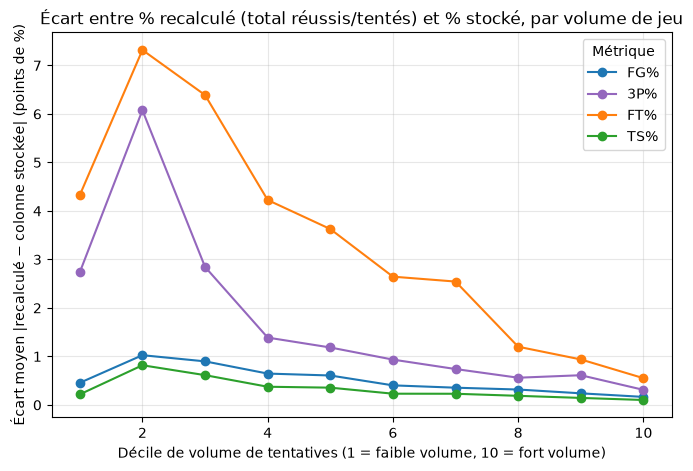

In [8]:
# Courbe écart vs volume (par décile de volume), une couleur par métrique
colors = {"FG%": "tab:blue", "3P%": "tab:purple", "FT%": "tab:orange", "TS%": "tab:green"}

fig, ax = plt.subplots(figsize=(8, 5))
for label, (volume, ecart) in ecarts_par_metrique.items():
    percentile = volume.rank(pct=True)  # 0 = faible volume, 1 = fort volume
    bins = pd.cut(percentile, bins=10, labels=False)
    courbe = ecart.groupby(bins).mean()
    ax.plot(courbe.index + 1, courbe.values, marker="o", color=colors[label], label=label)

ax.set_xlabel("Décile de volume de tentatives (1 = faible volume, 10 = fort volume)")
ax.set_ylabel("Écart moyen |recalculé − colonne stockée| (points de %)")
ax.set_title("Écart entre % recalculé (total réussis/tentés) et % stocké, par volume de jeu")
ax.legend(title="Métrique")
ax.grid(alpha=0.3)
plt.show()

Les 4 colonnes `%` montrent le même schéma : écart plus grand à faible volume, qui diminue à fort volume — signature typique d'une **moyenne des % match par match**, statistiquement différente d'un ratio sur les cumuls de saison (hypothèse plausible, non prouvée formellement : il faudrait des données par match pour la confirmer, absentes de ce fichier — voir section 1.7).

**Note a posteriori** : avant de découvrir que `3PM` était récupérable (section 1.4), deux formules avaient été testées pour l'estimer indirectement : `3PA × 3P%` et, via `EFG% = (FGM + 0.5×3PM)/FGA`, `3PM = 2×(EFG%×FGA − FGM)`. Comparées à la vraie valeur, `3PA × 3P%` s'est révélée assez proche (écart moyen réel : 1,09 tir) — bien plus fiable que la méthode `EFG%` (écart moyen : 2,74 tirs).

## 1.6 Vérifications complémentaires de cohérence interne

D'autres relations entre colonnes sont vérifiables sans donnée externe : `W+L` doit égaler `GP`, `REB` doit égaler `OREB+DREB`, `NETRTG` doit égaler `OFFRTG−DEFRTG`, `AST/TO` doit égaler `AST/TOV`.

In [9]:
# W+L = GP : vérifie que W/L sont bien des comptages par joueur, pas un total d'équipe répété
match_wl = (df["W"] + df["L"] == df["GP"]).mean() * 100
print(f"W + L = GP : {match_wl:.1f}% des lignes (569 au total)")

# REB = OREB + DREB
diff_reb = (df["OREB"] + df["DREB"]) - df["REB"]
print(f"\nREB = OREB + DREB : {(diff_reb==0).mean()*100:.1f}% exact, écart moyen={diff_reb.abs().mean():.2f}, max={diff_reb.abs().max():.0f}")

# NETRTG = OFFRTG - DEFRTG
diff_net = (df["OFFRTG"] - df["DEFRTG"]) - df["NETRTG"]
print(f"NETRTG = OFFRTG - DEFRTG : {(diff_net.abs()<0.05).mean()*100:.1f}% quasi-exact, écart max={diff_net.abs().max():.2f} (bruit d'arrondi)")

# AST/TO = AST / TOV (hors TOV=0, division non définie)
valid = df[df["TOV"] > 0]
diff_asttov = (valid["AST"] / valid["TOV"]) - valid["AST/TO"]
print(f"AST/TO = AST/TOV (hors {  (df['TOV']==0).sum() } lignes TOV=0) : écart médian={diff_asttov.abs().median():.3f}, max={diff_asttov.abs().max():.2f}")

W + L = GP : 100.0% des lignes (569 au total)

REB = OREB + DREB : 63.8% exact, écart moyen=1.32, max=8
NETRTG = OFFRTG - DEFRTG : 75.4% quasi-exact, écart max=0.10 (bruit d'arrondi)
AST/TO = AST/TOV (hors 19 lignes TOV=0) : écart médian=0.040, max=4.50


`W+L=GP` et `NETRTG=OFFRTG−DEFRTG` tiennent parfaitement (aux arrondis près). `REB=OREB+DREB` et `AST/TO=AST/TOV` divergent sur une partie notable des lignes — nouvelles incohérences à retenir, distinctes du problème des colonnes `%`.

## 1.7 Recherche d'une granularité par match (date, ID de match, domicile/extérieur)

Point critique pour le jeu de test RAGAS : les questions "meilleur % à 3 points sur les 5 derniers matchs" et "rebonds domicile vs extérieur" nécessitent une donnée par match.

In [10]:
keywords = ["date", "game", "match", "home", "away", "domicile", "ext", "vs", "opp"]
hits = [c for c in df.columns if any(k in str(c).lower() for k in keywords)]
print("Colonnes évoquant une notion de match/date/domicile-extérieur :", hits or "AUCUNE")
print("Nombre de lignes:", len(df), "| Nombre de joueurs uniques:", df["Player"].nunique())
print("-> Une ligne = un joueur, une seule fois. Aucune granularité par match dans cet onglet.")

Colonnes évoquant une notion de match/date/domicile-extérieur : AUCUNE
Nombre de lignes: 569 | Nombre de joueurs uniques: 569
-> Une ligne = un joueur, une seule fois. Aucune granularité par match dans cet onglet.


## 1.8 Conclusions de la section 1

**Le fichier ne contient que des agrégats de saison régulière par joueur** — une ligne par joueur, mélange de comptages (`GP`), de totaux de saison (`PTS`, `FGM`, `3PM`...), de moyennes par match (`Min`) et de taux déjà normalisés (`OFFRTG`, `PACE`...), **sans qu'aucune convention ne soit documentée**. Aucune granularité par match (date, domicile/extérieur) n'existe dans cet onglet.

**Conséquence pour `eval/testset.json`** : les questions "3 points sur les 5 derniers matchs" et "rebonds domicile/extérieur" restent **structurellement sans réponse calculable** avec ce dataset — pas un problème de retrieval, un problème de granularité des données.

**Bugs de qualité de données trouvés dans ce onglet** :
1. Nom de la colonne `3PM` corrompu en horaire par Excel — **données intactes**, simple renommage (pas de perte, contrairement à ce qu'on avait cru dans une première analyse).
2. Les colonnes `%` (`FG%`, `3P%`, `FT%`, `TS%`) ne correspondent pas à `réussis/tentés` sur les totaux de saison — écart corrélé au volume de jeu, plus fort pour les joueurs à faible volume.
3. `REB ≠ OREB+DREB` et `AST/TO ≠ AST/TOV` sur une partie notable des lignes — incohérences internes non documentées.
4. Le dictionnaire de données décrit `PTS`/`FGM`/`FGA` comme des "moyennes par match" alors que ce sont des totaux de saison.

**À retenir méthodologiquement** : ne jamais faire confiance à un nom ou une description de colonne sans vérifier empiriquement le contenu réel — plusieurs erreurs de cette analyse elle-même (voir le fil de discussion) sont venues du fait de ne pas avoir inspecté les valeurs, seulement les métadonnées (nom, type).

# 2. Onglet `Analyse`

## 2.1 Structure générale : plusieurs sous-tableaux empilés

Contrairement à `Données NBA`, cet onglet n'est pas une seule table — il contient plusieurs sections empilées verticalement dans les mêmes colonnes, chacune précédée d'un titre.

In [11]:
# Repère chaque section (titre en 1ère colonne, reste de la ligne vide) et sa ligne de départ
raw_analyse = xl.parse("Analyse", header=None)
non_vides = raw_analyse.dropna(how="all")
titres = non_vides[non_vides.iloc[:, 1:].isna().all(axis=1)]
print(f"Shape de l'onglet : {raw_analyse.shape}\n")
print("Sections détectées (ligne -> titre) :")
for idx, row in titres.iterrows():
    print(f"  ligne {idx}: {row.iloc[0]}")

Shape de l'onglet : (131, 8)

Sections détectées (ligne -> titre) :
  ligne 0: Analyse de la saison de NBA
  ligne 38: Analyse d'une équipe
  ligne 85: Analyse du top 15 des joueurs en nombre de points
  ligne 130: Analyse(s) complémentaire(s)


## 2.2 Tableau "équipes" (lignes 6-35) — validation croisée avec `Données NBA`

Ce tableau donne, par équipe, le nombre de joueurs et le total de points de saison. On le compare à la somme des `PTS` de `Données NBA` par équipe — une source indépendante pour confirmer que `PTS` est bien un total de saison (section 1.8).

In [12]:
# Chargement à l'identique, sans aucun calcul : juste vérifier que le tableau est bien capturé
end_row, end_col = bounding_box(raw_analyse, start_row=6)
print(f"Tableau équipes détecté : lignes 6-{end_row}, colonnes 0-{end_col} ({end_col + 1} colonnes)")

teams = raw_analyse.iloc[6:end_row + 1, :end_col + 1].copy()
teams.columns = ["Code", "Nom", "NbJoueurs", "PTS_total_analyse"]
teams

Tableau équipes détecté : lignes 6-35, colonnes 0-3 (4 colonnes)


,Code,Nom,NbJoueurs,PTS_total_analyse
6,MIA,Miami Heat,19,9828
7,OKC,Oklahoma City Thunder,18,9880
8,LAC,Los Angeles Clippers,17,9050
9,BKN,Brooklyn Nets,20,7999
10,ATL,Atlanta Hawks,18,9689
11,ORL,Orlando Magic,17,8648
12,BOS,Boston Celtics,17,9551
13,CLE,Cleveland Cavaliers,18,10180
14,DET,Detroit Pistons,19,10292
15,MIN,Minnesota Timberwolves,20,9523


Tableau chargé à l'identique. Maintenant les calculs : comparaison avec `Données NBA`.

In [13]:
teams["PTS_total_analyse"] = pd.to_numeric(teams["PTS_total_analyse"])

pts_calc = df.groupby("Team")["PTS"].sum()
teams["PTS_somme_donnees_NBA"] = teams["Code"].map(pts_calc)
teams["ecart"] = teams["PTS_total_analyse"] - teams["PTS_somme_donnees_NBA"]

print(f"Concordance exacte : {(teams['ecart']==0).sum()}/{len(teams)} équipes")
teams.head(6)

Concordance exacte : 30/30 équipes


,Code,Nom,NbJoueurs,PTS_total_analyse,PTS_somme_donnees_NBA,ecart
6,MIA,Miami Heat,19,9828,9828,0
7,OKC,Oklahoma City Thunder,18,9880,9880,0
8,LAC,Los Angeles Clippers,17,9050,9050,0
9,BKN,Brooklyn Nets,20,7999,7999,0
10,ATL,Atlanta Hawks,18,9689,9689,0
11,ORL,Orlando Magic,17,8648,8648,0


## 2.3 Section "Analyse d'une équipe" (ligne 38) — un PivotTable, pas un template vide

**Correction d'une erreur de cette analyse** : la grille XML de cette zone (lignes 43-62) est bien vide dans le fichier statique, mais **Excel y affiche des données** (constaté visuellement) — ce n'est pas un template abandonné, c'est un **tableau croisé dynamique (PivotTable)** dont Excel recalcule l'affichage à l'ouverture (`refreshOnLoad="1"`), sans jamais figer le résultat dans la feuille. `pandas`/`openpyxl` ne lisent que les cellules statiques : ils ne peuvent donc pas le voir, d'où l'erreur initiale.

Sa source (`xl/pivotCache/pivotCacheDefinition1.xml`) est `Données NBA!A2:AS571` — **exactement la table déjà extraite en `df`**. Le pivot n'apporte aucune donnée nouvelle : il recalcule, pour l'équipe sélectionnée dans son filtre, la somme de `OREB`/`DREB`/`PIE`/`AST`/`STL`/`BLK` par joueur — trivialement identique à lire directement ces colonnes dans `df` filtré sur l'équipe, puisque `Données NBA` a déjà une ligne unique par joueur.

In [14]:
# Vérification : le pivot filtré sur une équipe (ex. LAL, vu dans le fichier) est-il bien
# identique à une simple lecture de df, colonne par colonne, pour toute l'équipe (pas un seul joueur) ?
pivot_equivalent = df[df["Team"] == "LAL"][["Player", "OREB", "DREB", "PIE", "AST", "STL", "BLK"]]
print(f"{len(pivot_equivalent)} joueurs LAL trouvés dans Données NBA (comparer aux lignes visibles dans le PivotTable Excel)")
pivot_equivalent

20 joueurs LAL trouvés dans Données NBA (comparer aux lignes visibles dans le PivotTable Excel)


,Player,OREB,DREB,PIE,AST,STL,BLK
15,LeBron James,70,476,16.9,574,70,42
24,Austin Reaves,58,270,11.8,423,80,22
32,Luka Dončić,40,370,17.0,385,90,20
130,Rui Hachimura,77,218,8.6,83,47,24
151,Dalton Knecht,39,179,8.7,62,23,8
210,Dorian Finney-Smith,82,170,6.0,88,57,25
241,Gabe Vincent,22,72,3.9,101,50,14
276,Jaxson Hayes,78,190,9.7,56,34,50
305,Shake Milton,29,74,8.1,103,23,6
379,Jordan Goodwin,38,75,8.0,41,29,12


## 2.4 Tableau "Top 15 des joueurs en points" (lignes 89-103, colonnes A-H) — validation croisée

Une deuxième source indépendante pour `PTS`, `FGM`, `FG%`, `3P%`, `FT%`, `OREB` et `PIE`, sur les 15 meilleurs marqueurs. Table réellement large de 8 colonnes (identifiée grâce aux graphiques natifs du fichier, section 2.6 — une première extraction n'en avait pris que 5).

In [15]:
# Chargement à l'identique, sans aucun calcul : juste vérifier que le tableau est bien capturé
end_row, end_col = bounding_box(raw_analyse, start_row=89)
print(f"Tableau Top 15 détecté : lignes 89-{end_row}, colonnes 0-{end_col} ({end_col + 1} colonnes)")
print("-> C'est cette détection qui aurait évité l'erreur initiale (5 colonnes extraites au lieu de 8).")

top15 = raw_analyse.iloc[89:end_row + 1, :end_col + 1].copy()
top15.columns = ["Player", "PTS_top15", "FGM_top15", "FG%_top15", "3P%_top15",
                  "FT%_top15", "OREB_top15", "PIE_top15"]
top15

Tableau Top 15 détecté : lignes 89-103, colonnes 0-7 (8 colonnes)
-> C'est cette détection qui aurait évité l'erreur initiale (5 colonnes extraites au lieu de 8).


,Player,PTS_top15,FGM_top15,FG%_top15,3P%_top15,FT%_top15,OREB_top15,PIE_top15
89,Shai Gilgeous-Alexander,2485,859,51.9,37.5,89.8,68,19.9
90,Anthony Edwards,2180,719,44.7,39.5,83.7,63,14
91,Nikola Jokić,2072,784,57.6,41.7,80,203,20.6
92,Giannis Antetokounmpo,2037,791,60.1,22.2,61.7,147,21
93,Jayson Tatum,1930,662,45.2,34.3,81.4,50,15.8
94,Devin Booker,1920,653,46.1,33.2,89.4,75,12.2
95,Tyler Herro,1840,655,47.2,37.5,87.8,39,13.9
96,Trae Young,1839,562,41.1,34,87.5,38,12.9
97,Cade Cunningham,1827,686,46.9,35.6,84.6,56,15.2
98,James Harden,1801,529,41,35.2,87.4,55,14.5


Tableau chargé à l'identique. Maintenant les calculs : validation croisée avec `Données NBA`.

In [16]:
top15 = top15.set_index("Player")

verif = top15.join(df.set_index("Player")[["PTS", "FGM", "FG%", "3P%", "FT%", "OREB", "PIE"]])
for col in ["PTS", "FGM", "FG%", "3P%", "FT%", "OREB", "PIE"]:
    match = (verif[col] == verif[f"{col}_top15"]).all()
    print(f"{col}: concordance parfaite sur les 15 joueurs = {match}")

verif

PTS: concordance parfaite sur les 15 joueurs = True
FGM: concordance parfaite sur les 15 joueurs = True
FG%: concordance parfaite sur les 15 joueurs = True
3P%: concordance parfaite sur les 15 joueurs = True
FT%: concordance parfaite sur les 15 joueurs = True
OREB: concordance parfaite sur les 15 joueurs = True
PIE: concordance parfaite sur les 15 joueurs = True


,PTS_top15,FGM_top15,FG%_top15,3P%_top15,FT%_top15,OREB_top15,PIE_top15,PTS,FGM,FG%,3P%,FT%,OREB,PIE
Player,,,,,,,,,,,,,,
Shai Gilgeous-Alexander,2485,859,51.9,37.5,89.8,68,19.9,2485,859,51.9,37.5,89.8,68,19.9
Anthony Edwards,2180,719,44.7,39.5,83.7,63,14,2180,719,44.7,39.5,83.7,63,14.0
Nikola Jokić,2072,784,57.6,41.7,80,203,20.6,2072,784,57.6,41.7,80.0,203,20.6
Giannis Antetokounmpo,2037,791,60.1,22.2,61.7,147,21,2037,791,60.1,22.2,61.7,147,21.0
Jayson Tatum,1930,662,45.2,34.3,81.4,50,15.8,1930,662,45.2,34.3,81.4,50,15.8
Devin Booker,1920,653,46.1,33.2,89.4,75,12.2,1920,653,46.1,33.2,89.4,75,12.2
Tyler Herro,1840,655,47.2,37.5,87.8,39,13.9,1840,655,47.2,37.5,87.8,39,13.9
Trae Young,1839,562,41.1,34,87.5,38,12.9,1839,562,41.1,34.0,87.5,38,12.9
Cade Cunningham,1827,686,46.9,35.6,84.6,56,15.2,1827,686,46.9,35.6,84.6,56,15.2


Concordance parfaite sur les 7 colonnes et les 15 joueurs : les colonnes `%` ne sont pas des erreurs aléatoires — la même valeur apparaît de façon identique dans deux tableaux distincts du fichier, donc calculée délibérément et de façon cohérente (même si le mécanisme exact reste non prouvé, section 1.5).

## 2.5 Section "Analyse(s) complémentaire(s)" (ligne 130) — vide

Comme la section 2.3, un titre sans donnée en dessous (dernière ligne de l'onglet).

## 2.6 Graphiques natifs Excel

`pandas` ne lit que les valeurs des cellules — les graphiques natifs Excel (barres, courbes) ne sont visibles qu'avec `openpyxl`. C'est en les inspectant qu'on a découvert l'erreur d'extraction corrigée en section 2.4.

In [17]:
import openpyxl

wb = openpyxl.load_workbook(EXCEL_PATH, data_only=False)
for sheet_name in wb.sheetnames:
    n_charts = len(wb[sheet_name]._charts)
    if n_charts:
        print(f"{sheet_name}: {n_charts} graphique(s)")

print()
print("Détail des graphiques de 'Analyse' :")
for i, chart in enumerate(wb["Analyse"]._charts):
    # Extrait le texte du titre depuis l'objet Title imbriqué d'openpyxl
    titre = chart.title.tx.rich.p[0].r[0].t if chart.title else "(sans titre)"
    plages = [s.val.numRef.f for s in chart.series if s.val and s.val.numRef]
    print(f"  {i+1}. [{type(chart).__name__}] {titre!r} -> {plages}")

C:\Users\faiza\Formation_IA\Projet10_mission\.venv\Lib\site-packages\openpyxl\packaging\relationship.py:118: UserWarning: xl/pivotCache/_rels/pivotCacheDefinition1.xml.rels contains invalid dependency definitions
  warn(msg)


Analyse: 5 graphique(s)
Analyse Vide: 1 graphique(s)

Détail des graphiques de 'Analyse' :
  1. [BarChart] 'Visualisation des équipes' -> ['Analyse!$D$7:$D$36']
  2. [BarChart] 'Analyse des rebonds' -> ['Analyse!$B$43:$B$62', 'Analyse!$C$43:$C$62']
  3. [BarChart] 'Nombre de point total et Pourcentage de tirs réussis' -> ['Analyse!$B$90:$B$104']
  4. [BarChart] 'Analyse des Passes décisives, Interceptions et Contres ' -> ['Analyse!$E$43:$E$62', 'Analyse!$F$43:$F$62', 'Analyse!$G$43:$G$62']
  5. [LineChart] 'Pourcentage de tirs, de 3 points et le lancers francs réussis' -> ['Analyse!$D$90:$D$104', 'Analyse!$E$90:$E$104', 'Analyse!$F$90:$F$104']


**Bilan corrigé des 5 graphiques de `Analyse`** :
- **Graphique 1** (équipes) et **3, 5** (Top 15) : exploitables, pointent vers des données statiques déjà couvertes ci-dessus (2.2, 2.4).
- **Graphiques 2 et 4** ("Analyse des rebonds", "Analyse des Passes décisives...") : **pas cassés** — ils sont alimentés par le PivotTable de la section 2.3. Leurs plages (`B43:C62`, `E43:G62`) sont vides dans le fichier statique pour la même raison que le pivot lui-même (jamais figées, recalculées par Excel à l'ouverture). Ils fonctionnent normalement à l'ouverture du fichier dans Excel.

Comme le pivot, ces 2 graphiques ne reflètent aucune donnée en dehors de `Données NBA` — rien à en extraire pour la suite au-delà de ce qu'on a déjà dans `df`.

# 3. Onglet `Analyse Vide`

Même structure que `Analyse` (mêmes dimensions, mêmes titres de section, mêmes en-têtes de colonnes), et les cellules de données statiques sont bien vides. **Précision (section 2.3)** : cet onglet contient lui aussi un PivotTable (`A42:E51`), partageant le même cache que celui de `Analyse` — donc la même source `Données NBA`. C'est la version non configurée du même mécanisme (pas de filtre équipe sélectionné), cohérente avec son nom : un template interactif prêt à l'emploi, pas des données perdues.

In [18]:
raw_vide = xl.parse("Analyse Vide", header=None)
print("Mêmes dimensions que 'Analyse' :", raw_vide.shape == raw_analyse.shape)
print("Contenu strictement identique :", raw_analyse.equals(raw_vide))
print("Nombre de cellules non vides dans 'Analyse Vide' :", raw_vide.notna().sum().sum(),
      "contre", raw_analyse.notna().sum().sum(), "dans 'Analyse'")
raw_vide.dropna(how="all").head(8)

Mêmes dimensions que 'Analyse' : True
Contenu strictement identique : False
Nombre de cellules non vides dans 'Analyse Vide' : 46 contre 256 dans 'Analyse'


,0,1,2,3,4,5,6,7
0,Analyse de la saison de NBA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Code,Nom complet de l'équipe,Nombre de joueur par équipe,Nombre de point total par équipe,NaN,NaN,NaN,NaN
6,MIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,OKC,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,LAC,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,BKN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,ATL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,ORL,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 4. Onglet `Equipe`

Table de correspondance simple entre le code équipe (utilisé dans `Données NBA` et `Analyse`) et le nom complet de l'équipe.

In [19]:
# Chargement à l'identique, sans aucun calcul : juste vérifier que le tableau est bien capturé
raw_equipe = xl.parse("Equipe", header=None)
end_row, end_col = bounding_box(raw_equipe, start_row=0)
print(f"Tableau détecté : lignes 0-{end_row}, colonnes 0-{end_col} ({end_col + 1} colonnes)")

equipe = xl.parse("Equipe", header=0)
equipe

Tableau détecté : lignes 0-30, colonnes 0-1 (2 colonnes)


,Code,Nom complet de l'équipe
0,ATL,Atlanta Hawks
1,BKN,Brooklyn Nets
2,BOS,Boston Celtics
3,CHA,Charlotte Hornets
4,CHI,Chicago Bulls
5,CLE,Cleveland Cavaliers
6,DAL,Dallas Mavericks
7,DEN,Denver Nuggets
8,DET,Detroit Pistons
9,GSW,Golden State Warriors


Tableau chargé à l'identique. Maintenant les calculs : cohérence des codes équipe avec `Données NBA`.

In [20]:
print("Nombre de codes uniques:", equipe["Code"].nunique(), "| Nombre de codes équipe dans Données NBA:", df["Team"].nunique())
print("Tous les codes de Données NBA sont dans Equipe :", set(df["Team"]).issubset(set(equipe["Code"])))

Nombre de codes uniques: 30 | Nombre de codes équipe dans Données NBA: 30
Tous les codes de Données NBA sont dans Equipe : True


# 5. Onglet `Dictionnaire des données`

## 5.1 Chargement et contenu

Descriptions officielles des colonnes de `Données NBA`, fournies par le fichier source (abréviation → signification).

In [21]:
# Chargement à l'identique, sans aucun calcul : juste vérifier que le tableau est bien capturé
raw_dico = xl.parse("Dictionnaire des données", header=None)
end_row, end_col = bounding_box(raw_dico, start_row=1)
print(f"Tableau détecté : lignes 1-{end_row}, colonnes 0-{end_col} ({end_col + 1} colonnes)")

dico = raw_dico.iloc[1:end_row + 1, :end_col + 1].copy()
dico.columns = ["Abréviation", "Signification"]
dico = dico.reset_index(drop=True)
dico

Tableau détecté : lignes 1-45, colonnes 0-1 (2 colonnes)


,Abréviation,Signification
0,Player,Nom du joueur
1,Team,Équipe du joueur (code à 3 lettres)
2,Age,Âge du joueur
3,GP,Nombre de matchs joués (Games Played)
4,W,Nombre de victoires de l'équipe lors des match...
5,L,Nombre de défaites
6,Min,Minutes moyennes jouées par match
7,PTS,Points marqués en moyenne par match
8,FGM,Tirs réussis par match (Field Goals Made)
9,FGA,Tirs tentés par match (Field Goals Attempted)


## 5.2 Cohérence avec les colonnes de `Données NBA`

Le nombre de définitions doit correspondre au nombre de colonnes réelles (hors les 8 colonnes vides `Unnamed`, section 1.2).

In [22]:
# Colonnes réelles de Données NBA (hors les 8 colonnes vides Unnamed:45-52). "3PM" a été renommée
# en section 1.4 ; dans le dictionnaire, cette entrée reste corrompue (cf. cellule suivante).
colonnes_reelles = [c for c in df.columns if not str(c).startswith("Unnamed")]

print(f"Nombre de définitions dans le dictionnaire : {len(dico)}")
print(f"Nombre de colonnes réelles dans Données NBA : {len(colonnes_reelles)}")

noms_dico = set(dico["Abréviation"].astype(str))
manquantes = {str(c) for c in colonnes_reelles if c != "3PM"} - noms_dico
print("Colonnes de Données NBA absentes du dictionnaire (hors 3PM, corrompue des deux côtés) :", manquantes or "aucune")

Nombre de définitions dans le dictionnaire : 45
Nombre de colonnes réelles dans Données NBA : 45
Colonnes de Données NBA absentes du dictionnaire (hors 3PM, corrompue des deux côtés) : {'+/-'}


Les comptes correspondent (45 = 45). La seule "absence" détectée n'en est pas une : le dictionnaire écrit `"+ / -"` (avec espaces) alors que `Données NBA` utilise `"+/-"` — un problème de formatage entre les deux onglets, pas une définition manquante.

In [23]:
# L'entrée du dictionnaire pour la colonne 12 (section 1.4) a hérité de la même corruption Excel :
# c'est la seule Abréviation qui n'est pas une chaîne de caractères (type datetime.time).
ligne_3pm = dico[dico["Abréviation"].apply(lambda x: not isinstance(x, str))]
ligne_3pm

,Abréviation,Signification
11,15:00:00,Minutes jouées après 15:00 de jeu


# 6. Conclusion générale

**Pour `eval/testset.json`** :
- Les questions nécessitant une granularité par match ("5 derniers matchs", "domicile/extérieur") n'ont pas de réponse calculable — leur `reference_answer` doit être l'aveu de cette limite, pas un chiffre. C'est exactement ce que la métrique RAGAS **Faithfulness** doit sanctionner sur le prototype actuel (qui invente des chiffres au lieu de signaler l'absence de donnée).
- Les questions de classement/comparaison sur les stats de saison (`PTS`, `REB`, `AST`, `3P%`...) sont calculables et peuvent servir de cas "positifs" du jeu de test — en gardant à l'esprit les limites de fiabilité identifiées ci-dessus (`REB`, `AST/TO`, colonnes `%`).
- L'onglet `Analyse` (tableaux statiques + PivotTable) fournit des points de contrôle indépendants utiles pour construire des `reference_answer` vérifiées plutôt qu'approximatives — mais aucune donnée qui n'existe pas déjà dans `Données NBA`.

**Onglet/section sans contenu exploitable pour la suite** : uniquement la section 2.5 (`Analyse(s) complémentaire(s)`, réellement vide, sans PivotTable associé). `Analyse Vide` et la section 2.3 de `Analyse` ne sont **pas** des données perdues — ce sont des PivotTables recalculés par Excel, entièrement reproductibles depuis `Données NBA` (section 2.3).